In [16]:
import pandas as pd  # Data manipulation and analysis
import matplotlib.pyplot as plt  # Creating plots and visualizations
import seaborn as sns  # Statistical data visualization
from sklearn.linear_model import LinearRegression  # Linear regression modeling
from statsmodels.tsa.arima.model import ARIMA  # Time series forecasting
import numpy as np  # Numerical computing
from google.colab import files  # File downloading in Google Colab

In [17]:
# Load temperature data from CSV file
df = pd.read_csv('/content/drive/MyDrive/GlobalLandTemperaturesByCity.csv')

print(df.head())  # Display first 5 rows of the dataset

           dt  AverageTemperature  AverageTemperatureUncertainty   City  \
0  1743-11-01               6.068                          1.737  Århus   
1  1743-12-01                 NaN                            NaN  Århus   
2  1744-01-01                 NaN                            NaN  Århus   
3  1744-02-01                 NaN                            NaN  Århus   
4  1744-03-01                 NaN                            NaN  Århus   

   Country Latitude Longitude  
0  Denmark   57.05N    10.33E  
1  Denmark   57.05N    10.33E  
2  Denmark   57.05N    10.33E  
3  Denmark   57.05N    10.33E  
4  Denmark   57.05N    10.33E  


# **Data Cleaning & Preprocessing**

In [18]:
df = df.dropna(subset=['AverageTemperature'])  # Remove rows where temperature is missing

# Convert 'dt' column to datetime format
df['dt'] = pd.to_datetime(df['dt'])  # Change date string to proper datetime format

# Extract year and month for analysis
df['Year'] = df['dt'].dt.year  # Create new column for year
df['Month'] = df['dt'].dt.month  # Create new column for month

# Get unique list of countries
countries = sorted(df['Country'].unique())  # Get sorted list of all countries in data


In [19]:
# Print total number of countries in dataset
print(f"\n Total Countries in Dataset: {len(countries)}\n")

# Print header for country list
print("Country List:")

# Loop through each country and print its name
for country in countries:
    print("-", country)  # Print each country with bullet point


 Total Countries in Dataset: 159

Country List:
- Afghanistan
- Albania
- Algeria
- Angola
- Argentina
- Armenia
- Australia
- Austria
- Azerbaijan
- Bahamas
- Bahrain
- Bangladesh
- Belarus
- Belgium
- Benin
- Bolivia
- Bosnia And Herzegovina
- Botswana
- Brazil
- Bulgaria
- Burkina Faso
- Burma
- Burundi
- Cambodia
- Cameroon
- Canada
- Central African Republic
- Chad
- Chile
- China
- Colombia
- Congo
- Congo (Democratic Republic Of The)
- Costa Rica
- Croatia
- Cuba
- Cyprus
- Czech Republic
- Côte D'Ivoire
- Denmark
- Djibouti
- Dominican Republic
- Ecuador
- Egypt
- El Salvador
- Equatorial Guinea
- Eritrea
- Estonia
- Ethiopia
- Finland
- France
- Gabon
- Gambia
- Georgia
- Germany
- Ghana
- Greece
- Guatemala
- Guinea
- Guinea Bissau
- Guyana
- Haiti
- Honduras
- Hong Kong
- Hungary
- Iceland
- India
- Indonesia
- Iran
- Iraq
- Ireland
- Israel
- Italy
- Jamaica
- Japan
- Jordan
- Kazakhstan
- Kenya
- Laos
- Latvia
- Lebanon
- Lesotho
- Liberia
- Libya
- Lithuania
- Macedonia


# **Exploratory Data Analysis (EDA)**

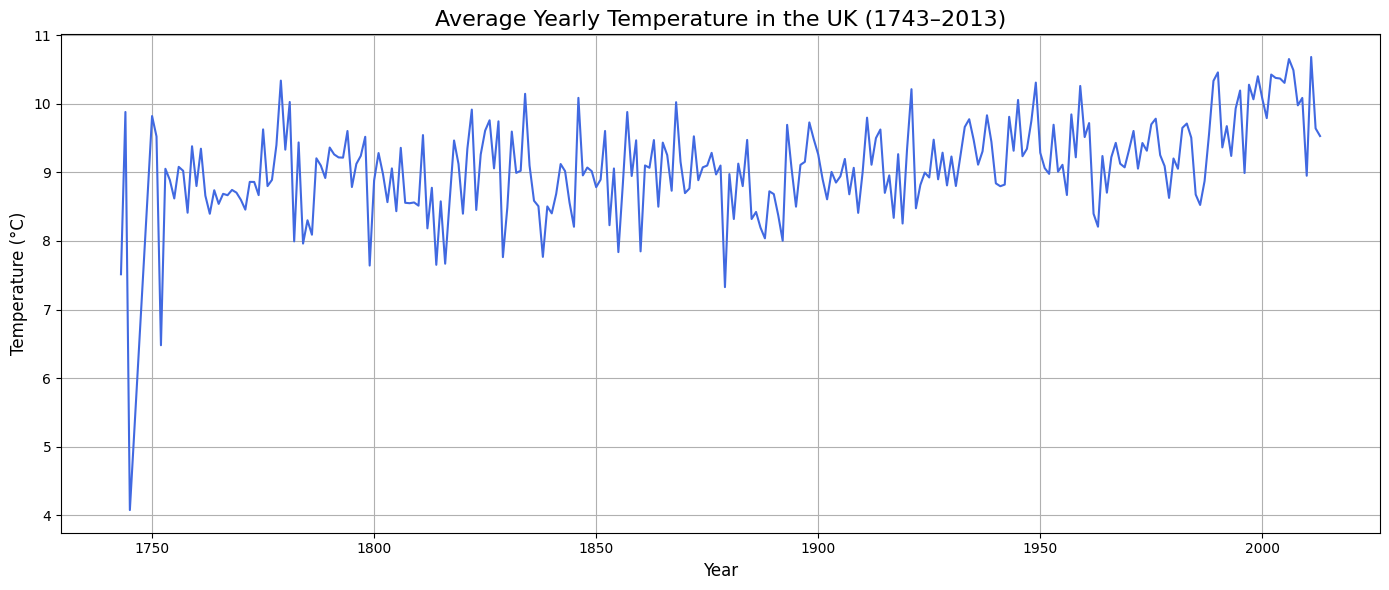

In [20]:
# Filter data for a specific country: UK
df_UK = df[df['Country'] == 'United Kingdom']

#Calculate Yearly Average Temperature for UK
yearly_avg = df_UK.groupby('Year')['AverageTemperature'].mean().reset_index()

# Plot yearly average temperature
plt.figure(figsize=(14, 6))
sns.lineplot(data=yearly_avg, x='Year', y='AverageTemperature', color='royalblue')
plt.title('Average Yearly Temperature in the UK (1743–2013)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipython-input-323044574.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette='coolwarm')  # Create bar chart with color gradient


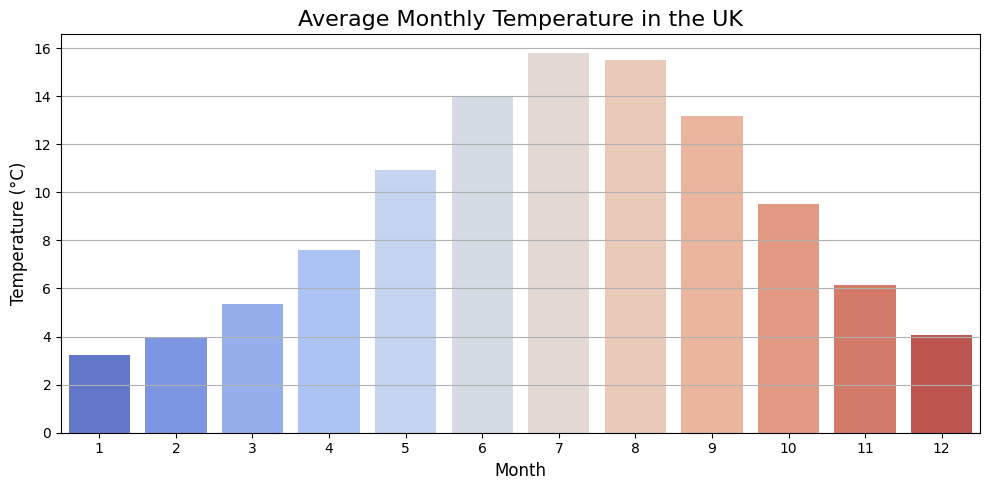

In [21]:
# Monthly Average Temperature Trend (Seasonal Insight)
monthly_avg = df_UK.groupby('Month')['AverageTemperature'].mean()  # Calculate average temperature for each month

plt.figure(figsize=(10, 5))  # Set plot size
sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette='coolwarm')  # Create bar chart with color gradient
plt.title('Average Monthly Temperature in the UK', fontsize=16)  # Add title
plt.xlabel('Month', fontsize=12)  # Label x-axis
plt.ylabel('Temperature (°C)', fontsize=12)  # Label y-axis
plt.grid(axis='y')  # Add horizontal grid lines
plt.tight_layout()  # Adjust spacing
plt.show()  # Display plot

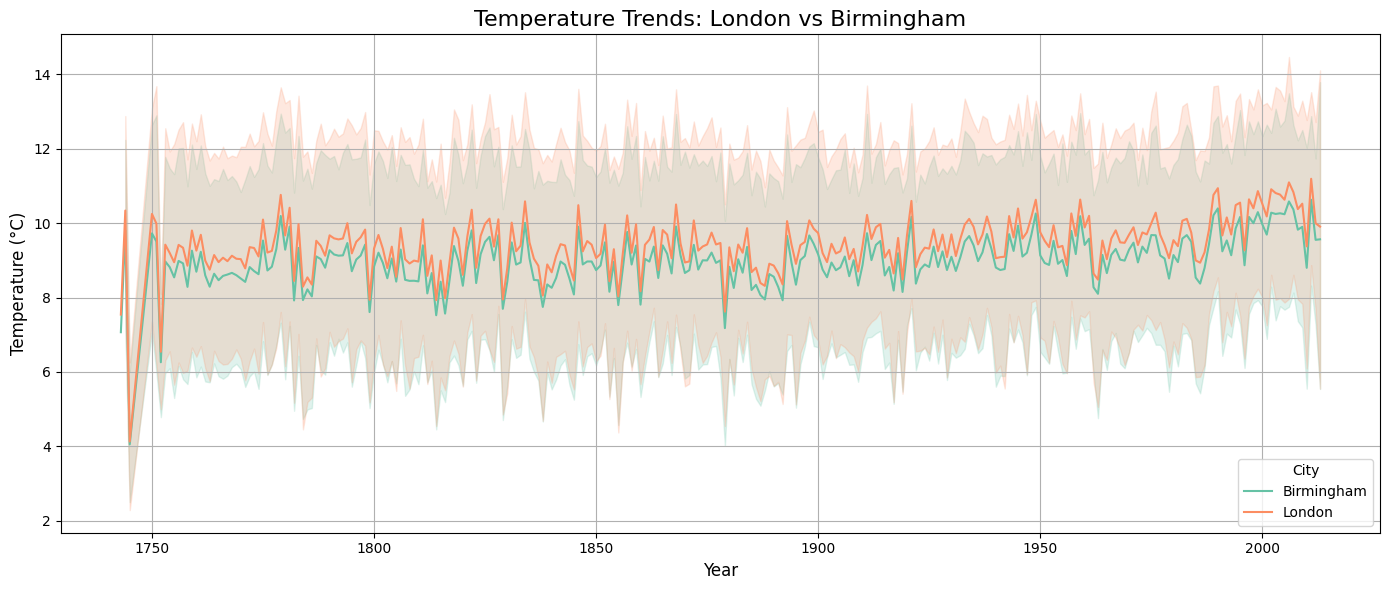

In [22]:
# Compare temperature trends between London and Birmingham
cities = ['London', 'Birmingham']  # Define cities to compare

# Filter the UK data for selected cities
df_cities = df_UK[df_UK['City'].isin(cities)]  # Get data only for London and Birmingham

# Plot temperature trends over years for each city
plt.figure(figsize=(14, 6))  # Set plot size
sns.lineplot(data=df_cities, x='Year', y='AverageTemperature', hue='City', palette='Set2')  # Create line plot with different colors per city
plt.title('Temperature Trends: London vs Birmingham', fontsize=16)  # Add title
plt.xlabel('Year', fontsize=12)  # Label x-axis
plt.ylabel('Temperature (°C)', fontsize=12)  # Label y-axis
plt.legend(title='City')  # Show legend with city names
plt.grid(True)  # Add grid lines
plt.tight_layout()  # Adjust spacing
plt.show()  # Display plot

# **Model Building**


Linear Regression Forecast Results:
----------------------------------------
Predicted Temperature for 2022: 10.24°C
Predicted Temperature for 2023: 10.26°C


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

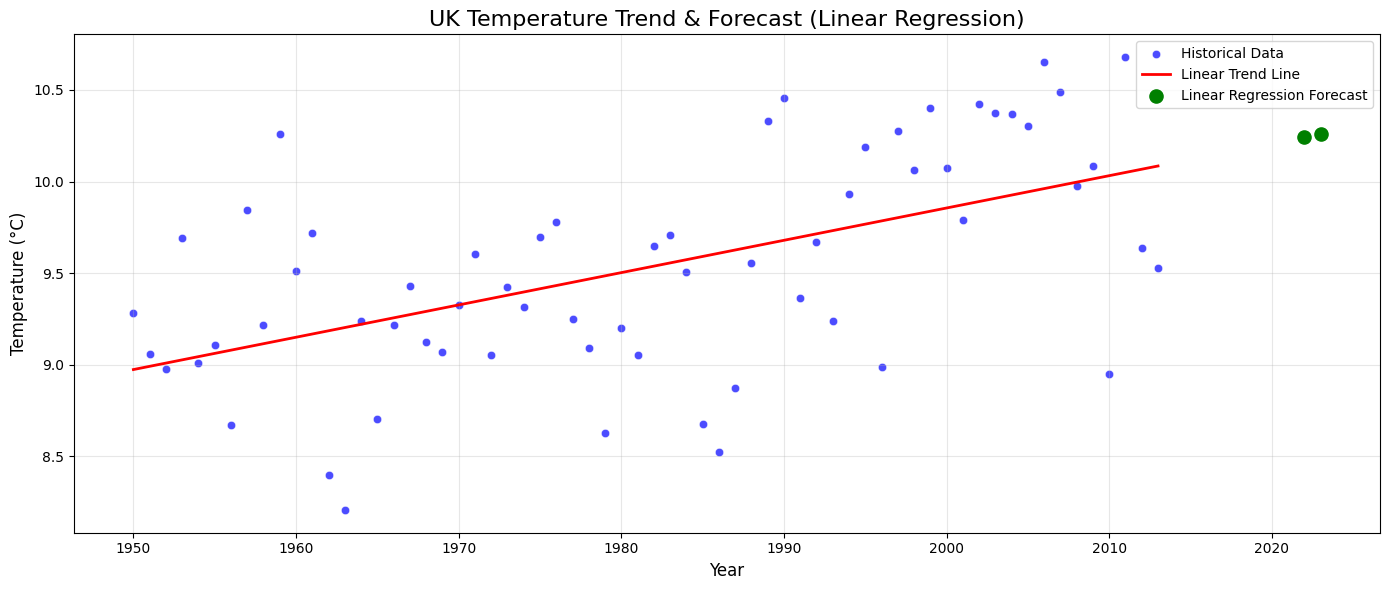

In [23]:
# LINEAR REGRESSION TEMPERATURE FORECAST

# Prepare data for Linear Regression
recent_data = yearly_avg[yearly_avg['Year'] >= 1950]  # Filter data from 1950
X_linear = recent_data['Year'].values.reshape(-1, 1)  # Feature: Year
y_linear = recent_data['AverageTemperature'].values   # Target: Temperature

# Train Linear Regression model
linear_model = LinearRegression()  # Create model
linear_model.fit(X_linear, y_linear)  # Train model

# Predict temperature for 2022 and 2023
future_years = np.array([2022, 2023]).reshape(-1, 1)  # Years to predict
predicted_linear = linear_model.predict(future_years)  # Make predictions

# Display results
print("\nLinear Regression Forecast Results:")
print("-" * 40)
print(f"Predicted Temperature for 2022: {predicted_linear[0]:.2f}°C")
print(f"Predicted Temperature for 2023: {predicted_linear[1]:.2f}°C")

# Create plot
plt.figure(figsize=(14, 6))
sns.scatterplot(x=recent_data['Year'], y=recent_data['AverageTemperature'],
                label='Historical Data', color='blue', alpha=0.7)  # Scatter plot

plt.plot(recent_data['Year'], linear_model.predict(X_linear),
         label='Linear Trend Line', color='red', linewidth=2)  # Trend line

plt.scatter(future_years, predicted_linear, color='green', s=90,
            label='Linear Regression Forecast', zorder=5)  # Predictions

plt.title('UK Temperature Trend & Forecast (Linear Regression)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend()  # Show legend
plt.grid(True, alpha=0.3)  # Add grid
plt.tight_layout()  # Adjust layout

# Save and download plot
plt.savefig("UK_Temperature_Linear_Regression_Forecast.png", dpi=300, bbox_inches='tight')
files.download("UK_Temperature_Linear_Regression_Forecast.png")  # Download file


plt.show()  # Display plot


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give


ARIMA Forecast Results:
----------------------------------------
Predicted Temperature in 2022: 9.86°C
Predicted Temperature in 2023: 9.92°C


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

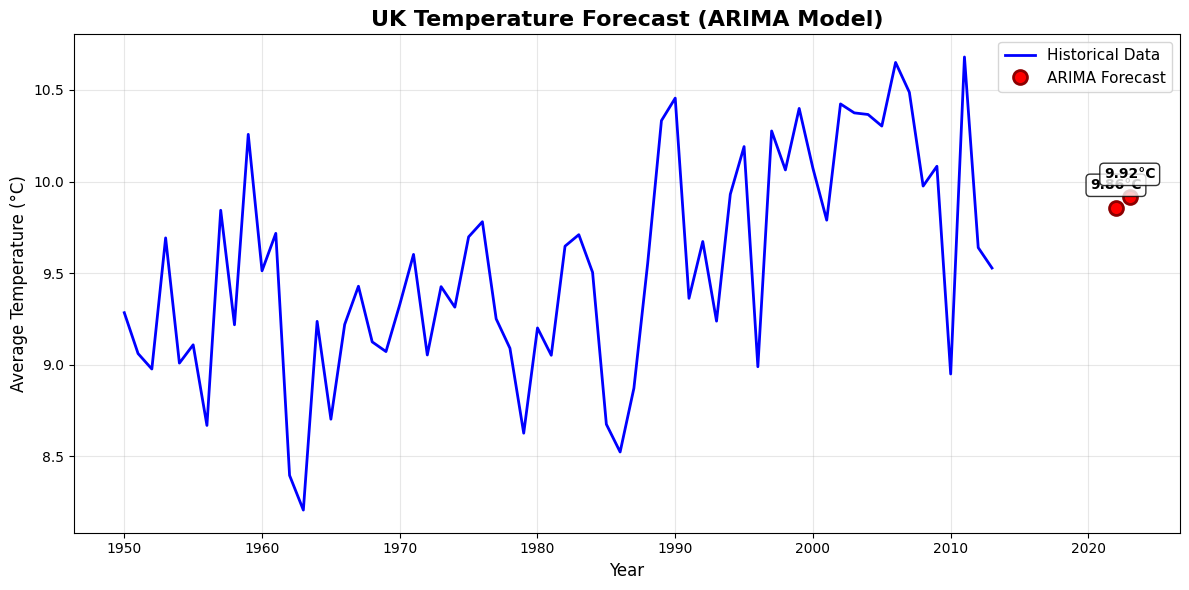

In [24]:
# ARIMA TIME SERIES FORECAST

# Prepare data for ARIMA
train_data = yearly_avg[yearly_avg['Year'] >= 1950]  # Use data from 1950

# Fit ARIMA model
arima_model = ARIMA(train_data['AverageTemperature'], order=(1, 1, 1)).fit()  # Train model

# Forecast next 2 years
arima_forecast = arima_model.forecast(steps=2)  # Predict 2022-2023
future_years_arima = [2022, 2023]  # Target years

# Display results
print("\nARIMA Forecast Results:")
print("-" * 40)
for year, temp in zip(future_years_arima, arima_forecast):
    print(f"Predicted Temperature in {year}: {temp:.2f}°C")


# Create plot
plt.figure(figsize=(12, 6))
sns.lineplot(x=train_data['Year'], y=train_data['AverageTemperature'],
             label='Historical Data', color='blue', linewidth=2)  # Historical line


# Plot forecast points as distinct red markers
plt.plot(
    future_years,  # X values: future years
    arima_forecast,  # Y values: forecasted temps
    'o',  # Circle markers
    color='red',  # Marker color
    label='ARIMA Forecast',  # Legend label
    markersize=10,  # Marker size
    markeredgecolor='darkred',  # Marker border color
    markeredgewidth=2  # Marker border width
)
    # Annotate forecast values above the points for clarity
for year, temp in zip(future_years_arima, arima_forecast):  # Loop through each forecast point
    plt.text(
        year,  # X position
        temp + 0.1,  # Y position (slightly above point)
        f"{temp:.2f}°C",  # Text to display
        ha='center',  # Horizontal alignment
        fontsize=10,  # Text size
        fontweight='bold',  # Text weight
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)  # Text background
    )

 # Configure plot aesthetics and labels
plt.title('UK Temperature Forecast (ARIMA Model)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Temperature (°C)', fontsize=12)
plt.legend(fontsize=11)  # Show legend
plt.grid(True, alpha=0.3)  # Add grid
plt.tight_layout()  # Adjust layout

# Save and download plot
plt.savefig("UK_Temperature_ARIMA_Forecast.png", dpi=300, bbox_inches='tight')
files.download("UK_Temperature_ARIMA_Forecast.png")  # Download file


plt.show()  # Display plot

# **Model Evaluation(RESULTS COMPARISON)**

In [25]:
# Print comparison header
print("\nTemperature Predictions Comparison (2022-2023):")
print("-" * 45)

# Print ARIMA predictions
print("\nARIMA Model Predictions:")
print(f"2022: {arima_forecast.iloc[0]:.2f}°C")  # Use list indexing
print(f"2023: {arima_forecast.iloc[1]:.2f}°C")

# Print Linear Regression predictions
print("\nLinear Regression Predictions:")
print(f"2022: {predicted_linear[0]:.2f}°C")
print(f"2023: {predicted_linear[1]:.2f}°C")

print("\nDifferences Between Models:")
print(f"2022 Difference: {abs(arima_forecast.iloc[0] - predicted_linear[0]):.2f}°C")
print(f"2023 Difference: {abs(arima_forecast.iloc[1] - predicted_linear[1]):.2f}°C")


Temperature Predictions Comparison (2022-2023):
---------------------------------------------

ARIMA Model Predictions:
2022: 9.86°C
2023: 9.92°C

Linear Regression Predictions:
2022: 10.24°C
2023: 10.26°C

Differences Between Models:
2022 Difference: 0.39°C
2023 Difference: 0.34°C
